In [3]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

IMAGE_SIZE = 128
NUM_CLASSES = 1

def create_dataset(samples=200):
    images = []
    labels = []

    for _ in range(samples):

        img = np.zeros((IMAGE_SIZE, IMAGE_SIZE, 3), dtype=np.uint8)

        x = np.random.randint(20, 90)
        y = np.random.randint(20, 90)
        w = np.random.randint(20, 40)
        h = np.random.randint(20, 40)

        cv2.rectangle(img, (x, y), (x + w, y + h), (255, 255, 255), -1)

        x_center = (x + w / 2) / IMAGE_SIZE
        y_center = (y + h / 2) / IMAGE_SIZE
        w = w / IMAGE_SIZE
        h = h / IMAGE_SIZE

        images.append(img / 255.0)
        labels.append([x_center, y_center, w, h, 1])

    return np.array(images), np.array(labels)

x, y = create_dataset()

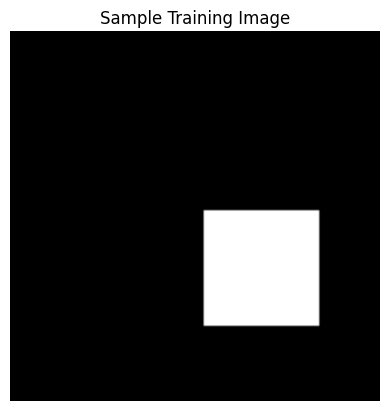

In [4]:
plt.imshow(x[0])
plt.title("Sample Training Image")
plt.axis("off")
plt.show()

In [9]:
# 2. Train / Test Split#

split = int(len(x)*0.8)

x_train, x_test = x[:split], x[split:]


y_train, y_test = y[:split], y[split:]

In [11]:


# Build a YOLO like CNN Model

model = tf.keras.Sequential([

    tf.keras.layers.Conv2D(16, (3, 3), activation='relu', input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3)),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),

    tf.keras.layers.Dense(5, activation='sigmoid')
])

model.compile(
  optimizer='adam',
  loss='mse'
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,629,989 (6.22 MB)

 Trainable params: 1,629,989 (6.22 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# 4. train Model

history = model.fit(
  x_train,
  y_train,
  validation_split=0.2,
  epochs=10,
  batch_size=8
)

Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - loss: 0.0191 - val_loss: 0.0079
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0049 - val_loss: 0.0048
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0022 - val_loss: 0.0027
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0014 - val_loss: 0.0020
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 9.5357e-04 - val_loss: 0.0020
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 6.4214e-04 - val_loss: 0.0017
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 4.1637e-04 - val_loss: 0.0016
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.7903e-04 - val_loss: 0.0015
Epoch 9/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.2919e-04 - val_loss: 0.0018
Epoch 10/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.0053e-04 - val_loss: 0.0017


In [13]:
# Evaluate Model

loss = model.evaluate(x_test, y_test)


print("Test Loss:", loss)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 290ms/step - loss: 0.0012
Test Loss: 0.001197154400870204


In [17]:
#IOU(Intersection Over Union)
def IOU(box1, box2):
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2

    x1_min = x1 - w1 / 2
    x1_max = x1 + w1 / 2
    y1_min = y1 - h1 / 2
    y1_max = y1 + h1 / 2

    x2_min = x2 - w2 / 2
    x2_max = x2 + w2 / 2
    y2_min = y2 - h2 / 2
    y2_max = y2 + h2 / 2

    inter_xmin = max(x1_min, x2_min)
    inter_ymin = max(y1_min, y2_min)
    inter_xmax = min(x1_max, x2_max)
    inter_ymax = min(y1_max, y2_max)

    inter_area = max(0, inter_xmax - inter_xmin) * max(0, inter_ymax - inter_ymin)

    area1 = w1 * h1
    area2 = w2 * h2

    union = area1 + area2 - inter_area

    return inter_area / union



In [18]:
# Test Predition
preds = model.predict(x_test[:5])
for i in range(5):
  pred_box = preds[i][:4]
  true_box = y_test[i][:4]

  iou = IOU (pred_box, true_box)

  print("\nExample", i+1)
  print("True Box:", true_box)
  print("Pred Box:", pred_box)
  print("IOU:", iou)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 797ms/step

Example 1
True Box: [0.73828125 0.72265625 0.2890625  0.1640625 ]
Pred Box: [0.7188559  0.7556937  0.26133424 0.25688276]
IOU: 0.5780489010199802

Example 2
True Box: [0.3125    0.5390625 0.265625  0.265625 ]
Pred Box: [0.2596848  0.54133385 0.22732177 0.16297343]
IOU: 0.4150436715554174

Example 3
True Box: [0.7890625  0.39453125 0.25       0.2890625 ]
Pred Box: [0.80236715 0.39771554 0.26699537 0.2451843 ]
IOU: 0.7745975472315496

Example 4
True Box: [0.5234375 0.3203125 0.296875  0.21875  ]
Pred Box: [0.52235514 0.25374907 0.23928796 0.19607265]
IOU: 0.43122978755492986

Example 5
True Box: [0.53515625 0.4765625  0.2578125  0.265625  ]
Pred Box: [0.53288794 0.47140518 0.24271983 0.21597262]
IOU: 0.7654751192783141
